# Predikce rizika diabetu pomocí strojového učení
### Zpracování informací a znalostí
###### 2025/2026  
###### Jména: Petr Dvořák, Duc Anh Tran, Ondřej Hájek, Adam Jandušík, Quang Danh Nguyen   


In [70]:
## Vše co je naformátované v markdown, tak je základ semestrálky a musíme vypracovat jako minimum. 
## V sekcích pro kód dávám vysvětlivky co tam musíme dát. Všechny code komentáře se potom musí smazat!!

## 0 Načtení knihoven a datasetu

In [71]:
## import knihoven
import pandas as pd
import numpy as np
import pandas as pd
import re
from io import StringIO
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib
## načtení datasetu # dunno jestli to můžem takhle udělat takže prozatimně takhle
df = pd.read_csv('diabetes_dataset.csv')
print(df)


     Age  Gender Polyuria Polydipsia weight_loss weakness Polyphagia  \
0     40    Male       No        Yes          No      Yes         No   
1     58    Male       No         No          No      Yes         No   
2     41    Male      Yes         No          No      Yes        Yes   
3     45    Male       No         No         Yes      Yes        Yes   
4     60    Male      Yes        Yes         Yes      Yes        Yes   
..   ...     ...      ...        ...         ...      ...        ...   
515   39  Female      Yes        Yes         Yes       No        Yes   
516   48  Female      Yes        Yes         Yes      Yes        Yes   
517   58  Female      Yes        Yes         Yes      Yes        Yes   
518   32  Female       No         No          No      Yes         No   
519   42    Male       No         No          No       No         No   

    Genital_thrush visual_blurring Itching Irritability delayed_healing  \
0               No              No     Yes           No     

## 1 Úvod

### 1.1 Byznysový význam
Diabetes patří mezi jednu z nejrozšířenějších civilizačních onemocnění, což představuje tedy významnou zátěž pro zdravotnictví a ekonomiku. Včasná identifikace rizikových pacientů by tedy umožnila preventivní zásahy, které by výrazně snížily náklady na léčbu komplikací spojených s pozdějšími stádii diabetu. Příkladem těchto komplikací může být např. kardiovaskulární onemocnění, selhání ledvin nebo poškození zraku.  

Z pohledu zdravotnictví může model strojového učení pomoci automatizovat předběžné vyhodnocení rizika diabetu na základě dostupných klinických a anamnestických údajů. To umožňuje lékařům soustředit se na pacienty s vyšším rizikem a zefektivnit diagnostický proces. Z pohledu byznysu by model mohl snížit náklady na pozdní léčbu, zvýšit kvalitu péče o pacienty a zlepšit alokaci zdravotnických zdrojů.

### 1.2  Odkaz na zdroj dat
Dataset je dostupný zde:  
https://www.openml.org/search?type=data&sort=version&status=any&order=asc&exact_name=diabetes_risk_prediction_dataset&id=46869

## 2  Přizpůsobení dat

### 2.1 Cílový atribut
* **Název**: _class (target)_
*  **Popis**: Říká jestli je pacient pozitivně nebo negativně diagnostikován s diabetem

### 2.2 Vybraná instance
* **Název**: _Polyuria_
* **Popis**: 

### 2.3 Atribut zájmu
* **Název**: _Polyuria_
* **Popis**:

### 2.4 Podmnožina zájmu
* **Název**: Pacienti s přítomností Polyuria  
* **Popis**: Podmnožina zájmu obsahuje všechny instance, u kterých je atribut Polyuria roven hodnotě „Yes“. Tato skupina pacientů byla vybrána, protože časté močení je jedním z typických příznaků diabetu a může indikovat zvýšené riziko onemocnění. Tato podmnožina je dále využita pro podrobnější analýzu vztahů mezi symptomy a cílovou proměnnou.

### 2.5  Matice nákladů

In [72]:
## Matice nákladů by mohla být dána uvedením nákladů na skutečně pozitivní výsledek (1), 
## skutečně negativní výsledek (1), falešně pozitivní výsledek (2) a falešně negativní výsledek (3). 
## Tím se vyjádří, že nejvyšší náklady vzniknou, když klasifikátor předpoví falešně negativní 
## diagnózu (pacient je predikován jako zdravý, ale ve skutečnosti má diabetes).
import pandas as pd
import numpy as np

TN_cost = 0
FP_cost = 2
FN_cost = 5
TP_cost = 1

cost_matrix = np.array([
    [TN_cost, FP_cost],
    [FN_cost, TP_cost]
])

cost_matrix_df = pd.DataFrame(
    cost_matrix,
    index=["Skutečně Negativní", "Skutečně Pozitivní"],
    columns=["Predikované Negativní", "Predikované Pozitivní"]
)

display(cost_matrix_df)

,Predikované Negativní,Predikované Pozitivní
Skutečně Negativní,0,2
Skutečně Pozitivní,5,1


## 3 Exploratorní analýza dat
Pro analýzu byly vybrány proměnné, které mají potenciální souvislost s přítomností diabetu nebo jsme je vybrali pro zajímavost.

* **class (target)** – cílová proměnná určující, zda pacient trpí diabetem  
* **Polyuria** – přítomnost nadměrného močení  
* **Polydipsia** – přítomnost nadměrné žízně  
* **Gender** – pohlaví pacienta  

### 3.1 Histogramy pro vybrané proměnné

#### 3.1.1 class (target)

Text(0, 0.5, 'Number of patients')

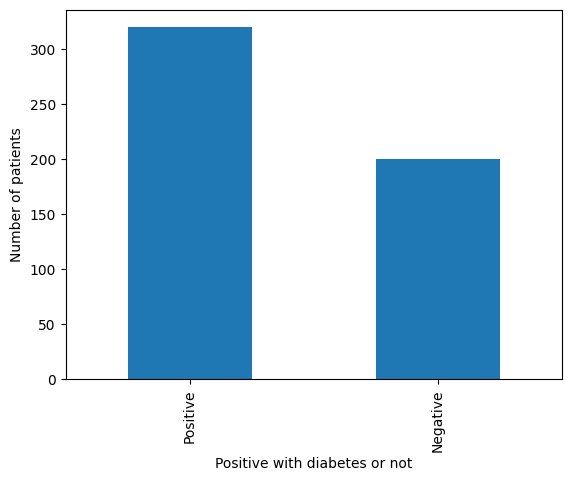

In [73]:
## Zobrazit histogram (nebo tabulku s četnostmi hodnot) pro cílovou proměnnou a pro 
## vybrané další proměnné.
df["class"].value_counts()

df["class"].value_counts().plot(kind='bar')
plt.xlabel('Positive with diabetes or not')
plt.ylabel('Number of patients')

#### 3.1.2 Polyuria

Text(0, 0.5, 'Number of patients')

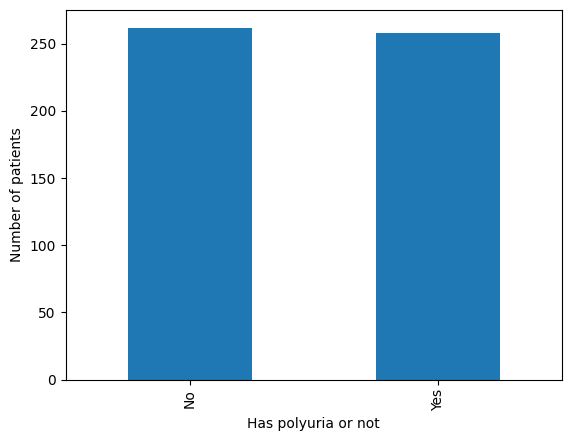

In [74]:
df["Polyuria"].value_counts()
 
df["Polyuria"].value_counts().plot(kind='bar')
plt.xlabel('Has polyuria or not')
plt.ylabel('Number of patients')

#### 3.1.3 Polydispia

Text(0, 0.5, 'Number of patients')

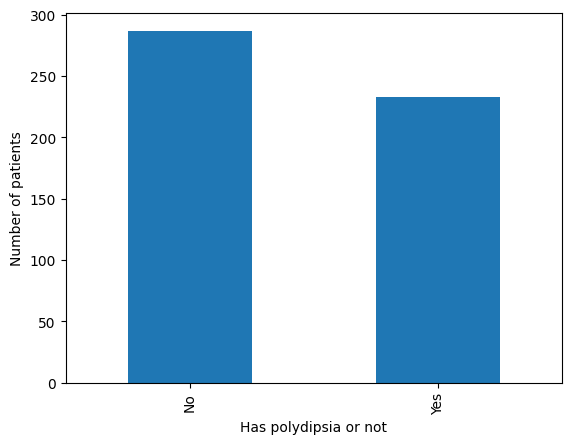

In [75]:
df["Polydipsia"].value_counts()

df["Polydipsia"].value_counts().plot(kind='bar')
plt.xlabel('Has polydipsia or not')
plt.ylabel('Number of patients')

#### 3.1.3 Age

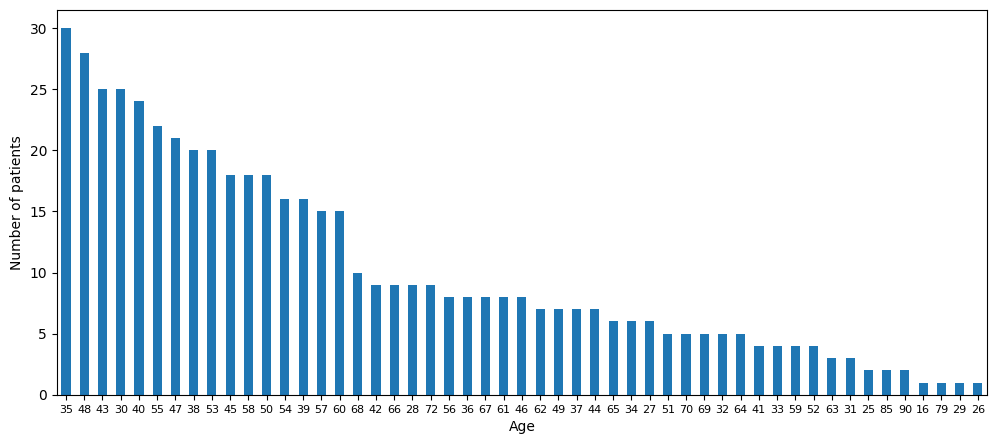

In [76]:
df["Age"].value_counts()

df["Age"].value_counts().plot(kind='bar', figsize=(12, 5))
plt.xlabel('Age')
plt.ylabel('Number of patients')
plt.tick_params(axis='x', labelsize=8, rotation=0)

### 3.2 Korelační graf

#### 3.2.1 Polyuria vs class(target)

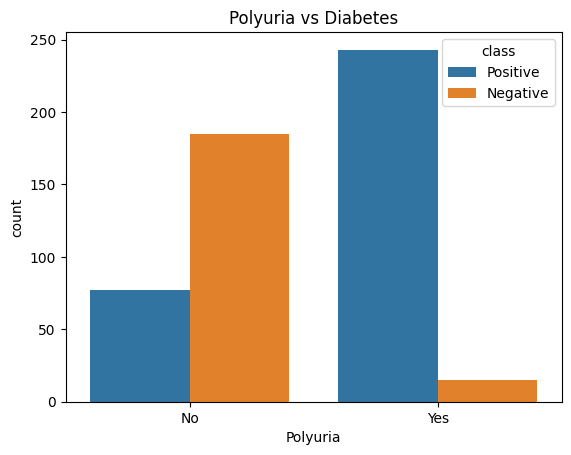

In [77]:
## Zobrazit graf rozptylu (korelační graf) znázorňující vztah mezi vybranými prediktory a 
## cílovou proměnnou.

##VERZE A (přehlednější)
import seaborn as sns

sns.countplot(x="Polyuria", hue="class", data=df)
plt.title("Polyuria vs Diabetes")
plt.show()   


#### 3.2.2 Polydipsia vs class(target)

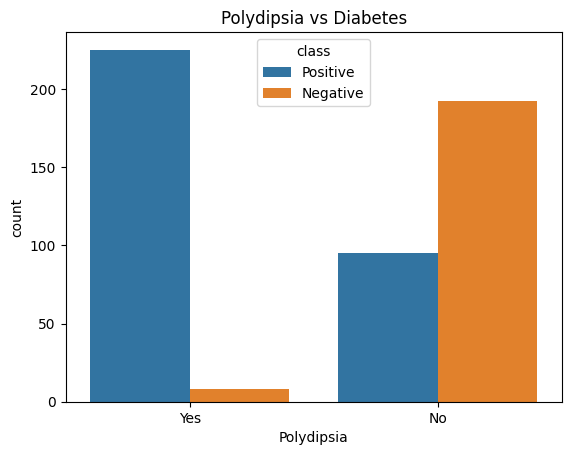

In [78]:
sns.countplot(x="Polydipsia", hue="class", data=df)

plt.title("Polydipsia vs Diabetes")
plt.show()

#### 3.2.3 Age vs class(target)

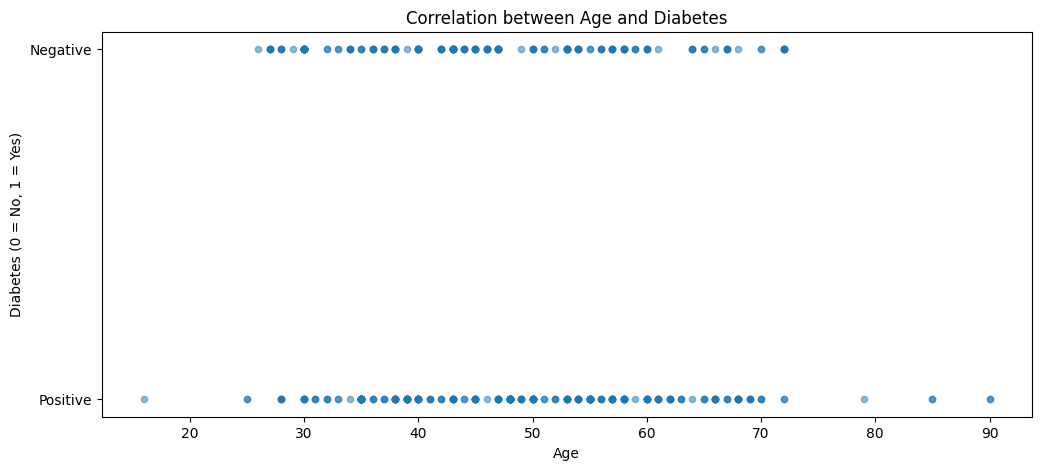

In [79]:
plt.figure(figsize=(12, 5))

plt.scatter(df["Age"], df["class"], alpha=0.5, s=20)

plt.xlabel("Age")
plt.ylabel("Diabetes (0 = No, 1 = Yes)")
plt.title("Correlation between Age and Diabetes")

plt.show()

In [80]:
## Bude jen krátký popis podle našich grafů.

### 3.3 Interpretace výsledků

Na základě histogramů cílové proměnné _class(target)_ bylo zjištěno, že dataset je nevyvážený, přičemž počet pacientů s diabetem značně převažuje počet pacientů s negativní diagnózou. Tato skutečnost může ovlivnit výběr vhodné metriky pro hodnocení modelu, proto může být vhodné využít F1-míru. Analýza vybraných proměnných ukázala, že některé atributy, zejména _Polyuria_ a _Polydipsia_, vykazují silnější vztah k výskytu diabetu. U těchto proměnných je patrný rozdíl v rozdělení mezi pozitivní a negativní třídou. Naopak proměnná _Age_ vykazuje pouze mírnou souvislost s cílovou proměnnou, což naznačuje, že tato proměnná není sama dostatečně spolehlivým prediktorem. 


## 4 Předzpracování dat

### 4.1 Předzpracování dat pro strojové učení s učitelem

In [81]:
## Petr, Adam, Tom
## a) Rozdělit data na trénovací a testovací
## b) Pokud jsou data nevyvážená tak trénovací soubor buď zvětšit nebo zmenšit pomocí převzorkování
## c) Feature selection - odstranění některých atributů
## Operace z předzpracování nepoužívá informace z testovací sady!!!

## KÓD
df["class"] = df["class"].map({"Positive": 1, "Negative": 0})

dataFrameCommon = df.drop(["Age", "Gender", "class"], axis=1)
featuresCommon = dataFrameCommon.columns

for x in featuresCommon:
    df[x] = df[x].map({'Yes':1, 'No':0})

df["Gender"] = df["Gender"].map({'Male':1,'Female':0})

#Splitting data - modify test size at your leasure, just tell everyone you did it
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2,random_state=42)


## Oversampling cuz it sounds better
negative = train[train["class"] == 0]
positive = train[train["class"] == 1]

negative_overs = negative.sample(
    n=len(positive),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([positive, negative_overs])

### 4.2 Předzpracování dat pro modely bez učitele

In [82]:
## Ondra, David
## a) Odstranit řádky, které nejsou v podskupině
## b) Normalizace třídy věku

## KÓD
df_unsup = pd.read_csv("diabetes_dataset.csv")

# převod kategorií na čísla
df_unsup["class"] = df_unsup["class"].map({"Positive": 1, "Negative": 0})

# Yes/No → 1/0
symptom_cols = [col for col in df_unsup.columns if col not in ["Age", "Gender", "class"]]

for col in symptom_cols:
    df_unsup[col] = df_unsup[col].map({"Yes": 1, "No": 0})

# Gender → číslo
df_unsup["Gender"] = df_unsup["Gender"].map({"Male": 1, "Female": 0})

# výběr podmnožiny
df_unsup = df_unsup[df_unsup["Polyuria"] == 1].copy()

# ODSTRANĚNÍ TARGETU ... učení bez učitele
X_unsup = df_unsup.drop(columns=["class"])

# škálování dat (důležité pro clustering)
scaler = StandardScaler()
X_unsup_scaled = scaler.fit_transform(X_unsup)

## 5 Modelování dat

In [83]:
## Popsat použité parametry

### 5.1 Klasifikační modely

In [84]:
## a) Trénovat model na trénovacích datech a vyhodnotit ho na testovacích datech
## b) Vyzkoušet různé kombinace metaparametrů (např. hloubka stromu, počet stromů v lese atd.) 

#### 5.1.1 Rozhodovací stromy

In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

depths = range(1, 21)

scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)
    score = f1_score(y_test, y_pred)

    scores.append(score)
    print(f"Depth {d}: F1 = {score:.4f}")

Depth 1: F1 = 0.8346
Depth 2: F1 = 0.8905
Depth 3: F1 = 0.9444
Depth 4: F1 = 0.9481
Depth 5: F1 = 0.9635
Depth 6: F1 = 0.9559
Depth 7: F1 = 0.9635
Depth 8: F1 = 0.9857
Depth 9: F1 = 0.9857
Depth 10: F1 = 0.9857
Depth 11: F1 = 0.9857
Depth 12: F1 = 0.9857
Depth 13: F1 = 0.9857
Depth 14: F1 = 0.9857
Depth 15: F1 = 0.9857
Depth 16: F1 = 0.9857
Depth 17: F1 = 0.9857
Depth 18: F1 = 0.9857
Depth 19: F1 = 0.9857
Depth 20: F1 = 0.9857


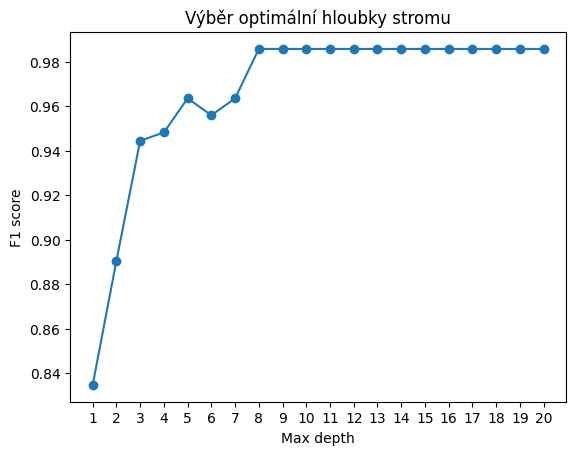

In [86]:
plt.plot(depths, scores, marker='o')
plt.xticks(range(1, 21))
plt.xlabel("Max depth")
plt.ylabel("F1 score")
plt.title("Výběr optimální hloubky stromu")
plt.show()

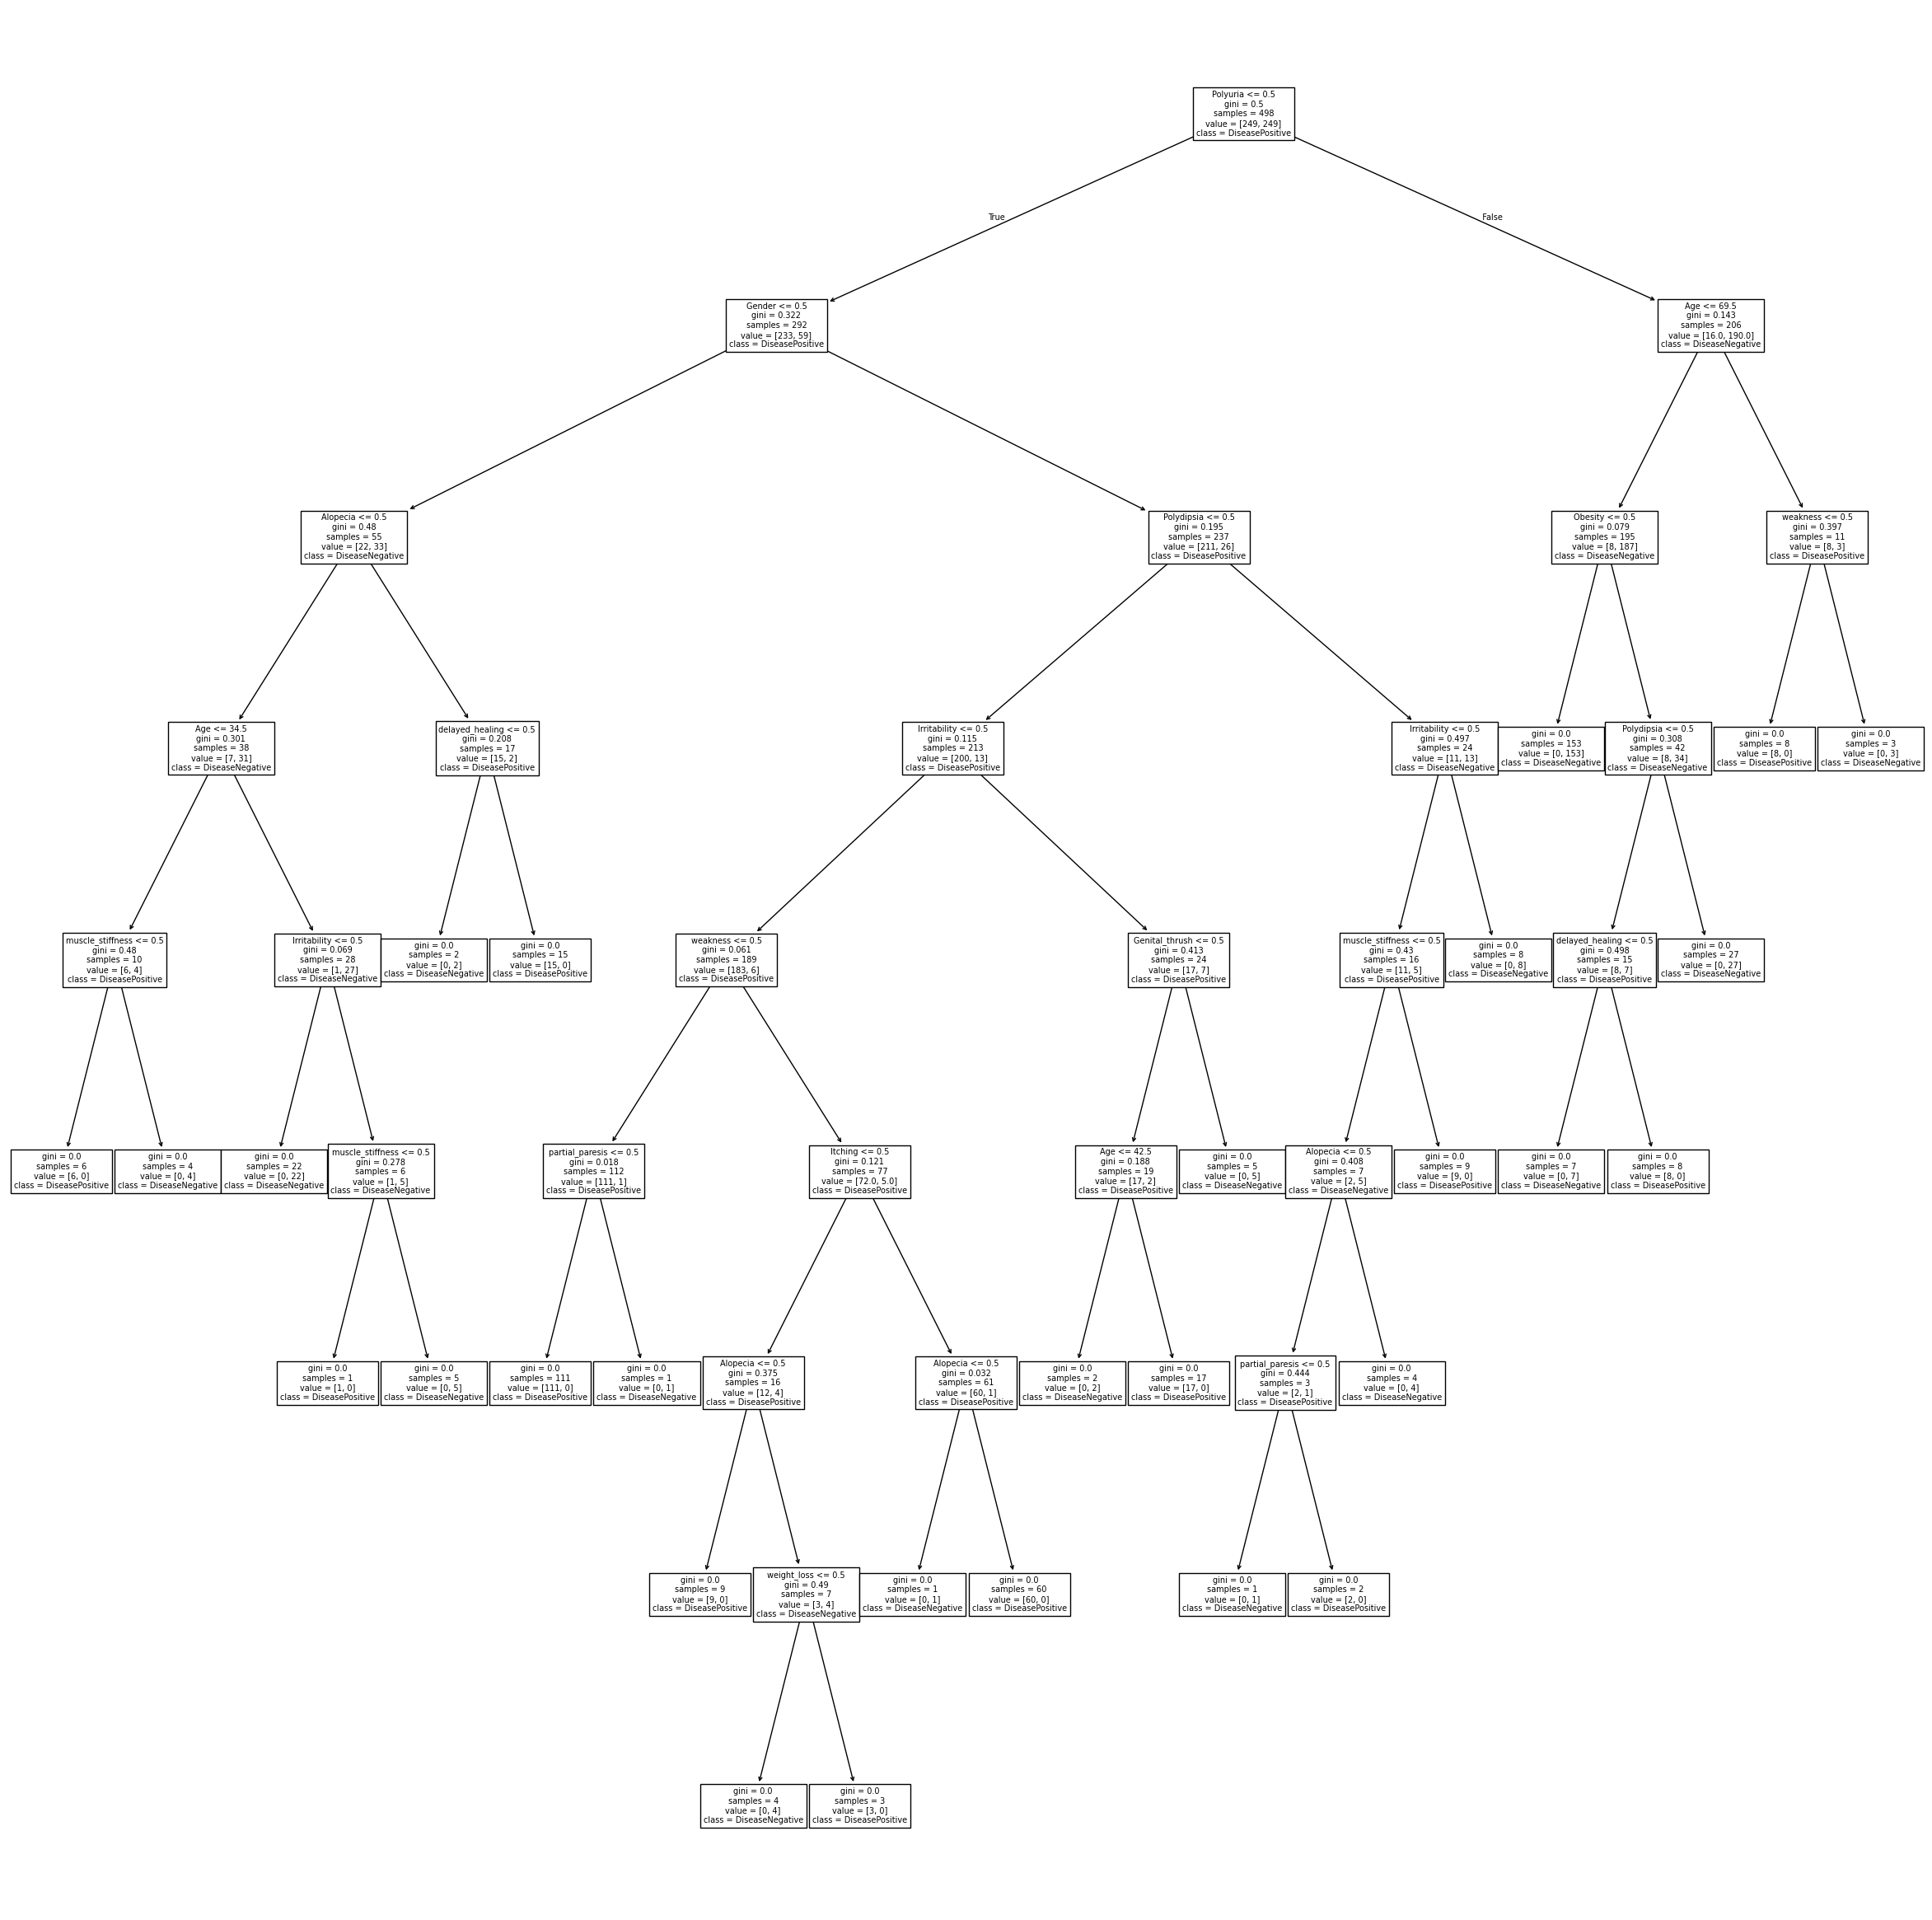

In [88]:
## KÓD
x_train = train_balanced.drop(columns=["class"])
y_train = train_balanced[["class"]]
x_test = test.drop(columns=['class'])
y_test = test[['class']]

decisionTreeClasiffier = DecisionTreeClassifier(random_state=42, max_depth=8)
decisionTreeClasiffier.fit(x_train,y_train)

pred = decisionTreeClasiffier.predict(x_test)
#print(pred)


plt.figure(figsize=(30,30))

dtcClasses=["DiseasePositive","DiseaseNegative"]
x=plot_tree(decisionTreeClasiffier, feature_names=decisionTreeClasiffier.feature_names_in_, class_names=dtcClasses)

## Dvakrát klikněte na strom pro zvětšení

#### 5.1.1 Náhodné lesy

In [89]:
## KÓD

# Random Forest budeme trénovat na stejných datech jako rozhodovací strom, aby šlo výsledky porovnat.
# Chceme 100 stromů
pocet_stromu = 70
hloubka_stromu = 4
randomForestClassifier = RandomForestClassifier(
    n_estimators=pocet_stromu,
    max_depth=hloubka_stromu,
    random_state=42
)

# trénování
randomForestClassifier.fit(x_train, y_train.values.ravel()) # chceme 1D pole z 2D

# predikce
pred = randomForestClassifier.predict(x_test)


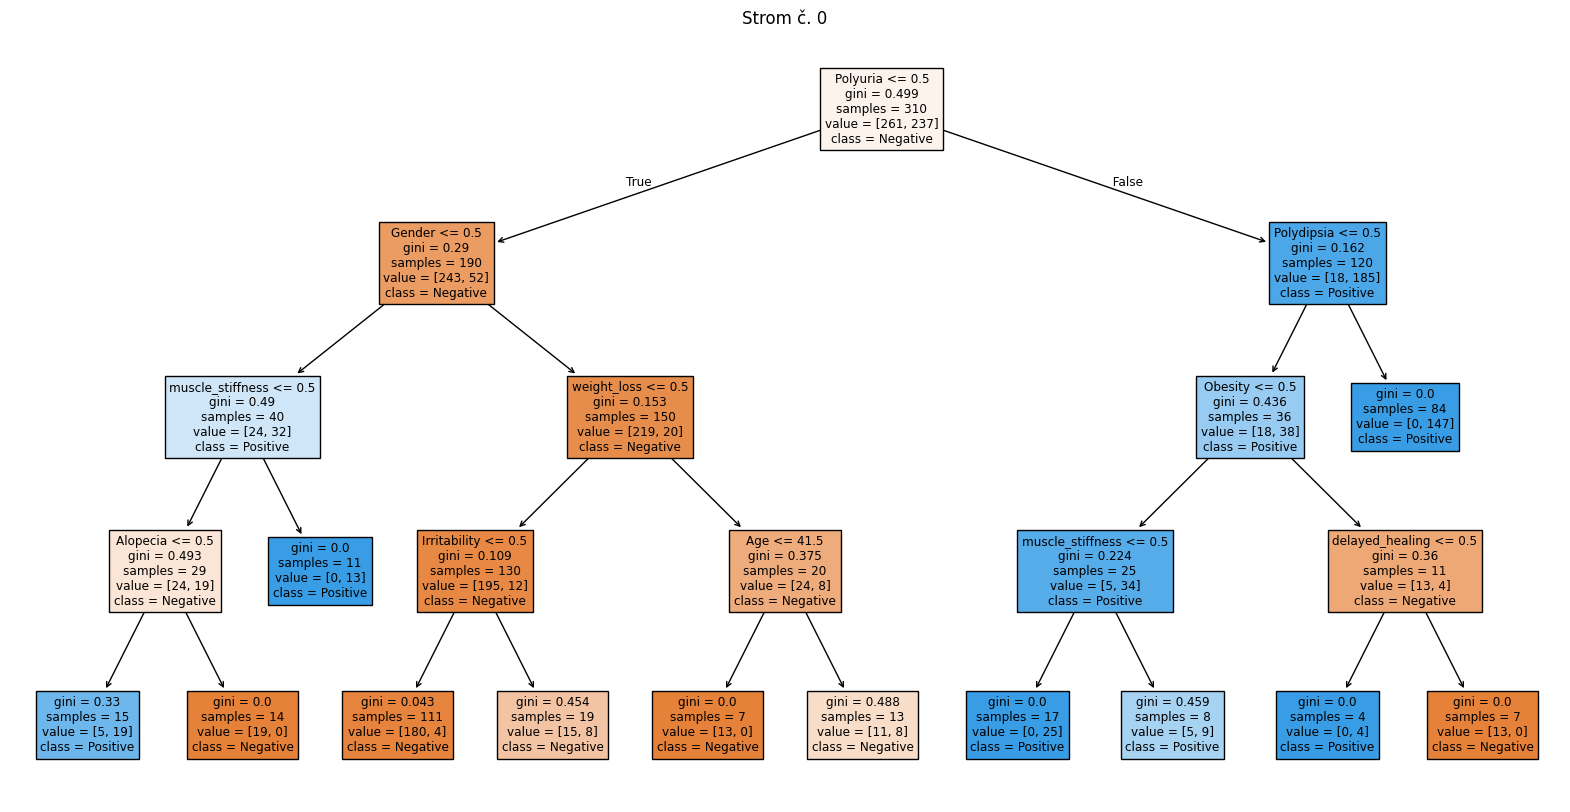

In [90]:
# příklad: první strom ze 100 stromů v Random Forest
first_tree = randomForestClassifier.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    first_tree,
    feature_names=x_train.columns,
    class_names=["Negative", "Positive"],
    filled=True,
    max_depth=4
)
plt.title("Strom č. 0")
plt.show()

In [91]:
## KÓD

# Random Forest budeme trénovat na stejných datech jako rozhodovací strom, aby šlo výsledky porovnat.
# Chceme 100 stromů
pocet_stromu = 100
hloubka_stromu = 11
randomForestClassifier = RandomForestClassifier(
    n_estimators=pocet_stromu,
    max_depth=hloubka_stromu,
    random_state=42
)

# trénování
randomForestClassifier.fit(x_train, y_train.values.ravel()) # chceme 1D pole z 2D

# predikce
pred = randomForestClassifier.predict(x_test)


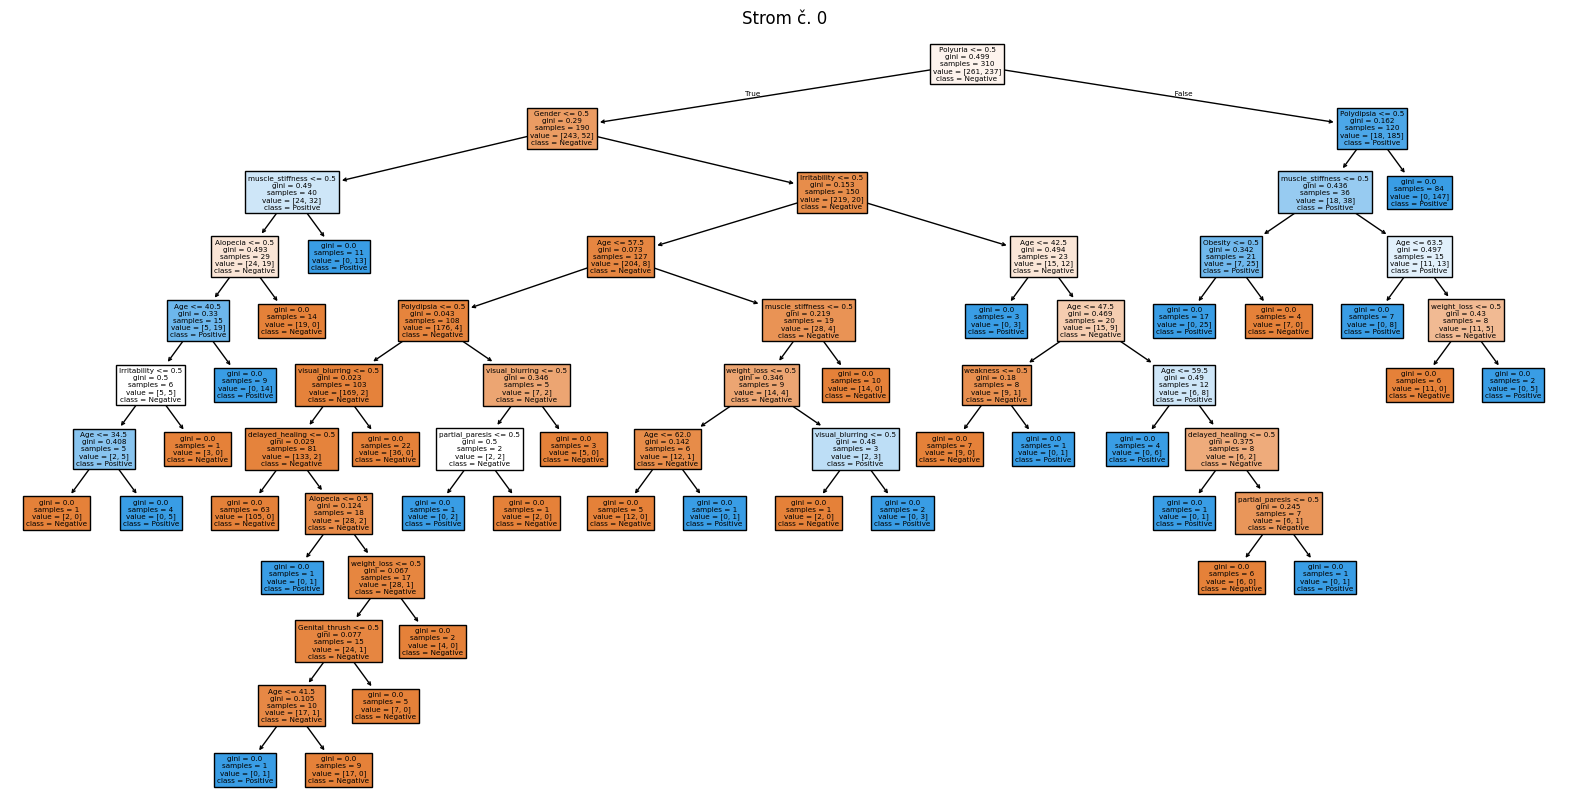

In [92]:
# příklad: první strom ze 100 stromů v Random Forest
first_tree = randomForestClassifier.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    first_tree,
    feature_names=x_train.columns,
    class_names=["Negative", "Positive"],
    filled=True,
    max_depth=11
)
plt.title("Strom č. 0")
plt.show()

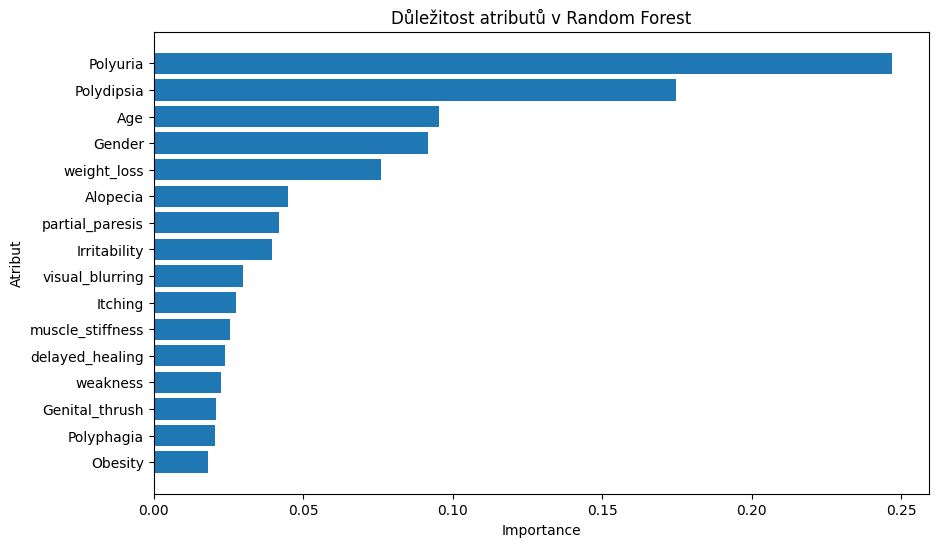

In [93]:
#Graf: jak moc každá featura hraje roli v predikci

#random forest umi výpočítat důležitost pro každou featuru z naších 100 stromů

# hodnota důležitosti např. [0.5, 0.32, 0.25, atd...]
importances = randomForestClassifier.feature_importances_
# nazev těch featur
features = x_train.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Důležitost atributů v Random Forest")
plt.xlabel("Importance")
plt.ylabel("Atribut")
plt.show()

#interpretace výsledků (viz grafu)
  # vidíme, že polydipsia má nejvyšší hodnotu 
    #(např. pokud člověk chodí často na záchod, je to vysoká pravděpodobnost, že má diabetu)

### 5.2 Shlukovací modely

In [94]:
## a) Vyzkoušet různá nastavení shlukování
## b) Vyzkoušet různá nastavení metaparametrů (např. pošet shluků pro k-means)
## c) Vybrat nejvhodnější hodnotu

#### 5.2.1 Ploché shlukování

In [95]:
## KÓD
# různá nastavení shlukování
for k in [2, 3, 4, 5, 6]:
    print(f"K = {k}")
    
    kmeans_model = KMeans(n_clusters=k, random_state=42)
    labels_kmeans = kmeans_model.fit_predict(X_unsup_scaled)

    # přidáme sloupec "cluster" (viz tab dole)
    df_kmeans_temp = df_unsup.copy()
    df_kmeans_temp["cluster_kmeans"] = labels_kmeans
    
    print("Počet lidí ve shlucích:")
    print(df_kmeans_temp["cluster_kmeans"].value_counts().sort_index())
    
    print("Průměry:")
    display(df_kmeans_temp.groupby("cluster_kmeans").mean(numeric_only=True))

K = 2
Počet lidí ve shlucích:
cluster_kmeans
0    115
1    143
Name: count, dtype: int64
Průměry:


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster_kmeans,,,,,,,,,,,,,,,,,
0,52.191304,0.86087,1.0,0.486957,0.513043,0.521739,0.513043,0.521739,0.417391,0.513043,0.417391,0.460870,0.330435,0.391304,0.591304,0.260870,0.869565
1,49.090909,0.20979,1.0,0.958042,0.741259,0.874126,0.748252,0.048951,0.685315,0.545455,0.286713,0.594406,0.909091,0.496503,0.020979,0.181818,1.000000


K = 3
Počet lidí ve shlucích:
cluster_kmeans
0     74
1    121
2     63
Name: count, dtype: int64
Průměry:


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster_kmeans,,,,,,,,,,,,,,,,,
0,46.310811,0.810811,1.0,0.500000,0.527027,0.418919,0.283784,0.540541,0.216216,0.391892,0.324324,0.324324,0.229730,0.229730,0.459459,0.175676,0.945946
1,46.669421,0.107438,1.0,0.958678,0.752066,0.867769,0.776860,0.033058,0.636364,0.537190,0.214876,0.628099,0.925620,0.438017,0.000000,0.157025,1.000000
2,62.666667,0.888889,1.0,0.634921,0.555556,0.777778,0.809524,0.365079,0.841270,0.682540,0.619048,0.603175,0.619048,0.730159,0.587302,0.380952,0.825397


K = 4
Počet lidí ve shlucích:
cluster_kmeans
0    47
1    67
2    76
3    68
Name: count, dtype: int64
Průměry:


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster_kmeans,,,,,,,,,,,,,,,,,
0,44.212766,0.702128,1.0,0.361702,0.553191,0.170213,0.404255,0.340426,0.170213,0.234043,0.234043,0.276596,0.212766,0.234043,0.361702,0.148936,1.000000
1,50.552239,0.343284,1.0,0.985075,0.791045,1.000000,0.492537,0.044776,0.805970,0.194030,0.179104,0.134328,0.820896,0.417910,0.044776,0.298507,1.000000
2,47.539474,0.144737,1.0,0.986842,0.657895,0.763158,0.894737,0.052632,0.565789,0.855263,0.407895,0.907895,0.986842,0.513158,0.000000,0.052632,1.000000
3,58.000000,0.911765,1.0,0.514706,0.529412,0.764706,0.676471,0.647059,0.602941,0.705882,0.514706,0.691176,0.411765,0.558824,0.750000,0.367647,0.779412


K = 5
Počet lidí ve shlucích:
cluster_kmeans
0    35
1    63
2    75
3    42
4    43
Name: count, dtype: int64
Průměry:


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster_kmeans,,,,,,,,,,,,,,,,,
0,45.628571,0.628571,1.0,0.314286,0.571429,0.142857,0.514286,0.114286,0.200000,0.057143,0.257143,0.257143,0.257143,0.171429,0.400000,0.085714,1.000000
1,48.873016,0.269841,1.0,0.968254,0.777778,0.936508,0.634921,0.000000,0.730159,0.063492,0.095238,0.253968,0.904762,0.412698,0.031746,0.269841,1.000000
2,49.013333,0.133333,1.0,0.973333,0.693333,0.800000,0.813333,0.080000,0.666667,0.960000,0.453333,0.853333,0.946667,0.560000,0.000000,0.106667,1.000000
3,63.785714,0.880952,1.0,0.452381,0.476190,0.666667,0.928571,0.428571,0.714286,0.666667,0.547619,0.809524,0.547619,0.809524,0.880952,0.380952,0.738095
4,46.302326,1.000000,1.0,0.674419,0.558140,0.767442,0.186047,0.906977,0.302326,0.720930,0.395349,0.348837,0.186047,0.186047,0.418605,0.279070,0.906977


K = 6
Počet lidí ve shlucích:
cluster_kmeans
0    36
1    48
2    34
3    37
4    38
5    65
Name: count, dtype: int64
Průměry:


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster_kmeans,,,,,,,,,,,,,,,,,
0,45.305556,0.611111,1.0,0.333333,0.555556,0.166667,0.500000,0.111111,0.194444,0.055556,0.277778,0.250000,0.250000,0.194444,0.388889,0.083333,1.000000
1,50.750000,0.333333,1.0,1.000000,0.729167,1.000000,0.750000,0.000000,0.750000,0.020833,0.083333,0.125000,0.895833,0.291667,0.041667,0.354167,1.000000
2,61.823529,0.411765,1.0,0.882353,0.264706,0.852941,0.588235,0.352941,0.882353,0.970588,0.323529,0.647059,0.823529,0.323529,0.000000,0.147059,1.000000
3,62.702703,0.864865,1.0,0.432432,0.486486,0.621622,0.918919,0.351351,0.702703,0.621622,0.540541,0.810811,0.486486,0.837838,1.000000,0.405405,0.702703
4,45.289474,1.000000,1.0,0.631579,0.631579,0.736842,0.184211,0.973684,0.263158,0.710526,0.421053,0.342105,0.157895,0.210526,0.473684,0.315789,0.894737
5,43.261538,0.107692,1.0,0.969231,0.907692,0.784615,0.784615,0.015385,0.569231,0.784615,0.430769,0.892308,0.984615,0.692308,0.000000,0.061538,1.000000


Byly vyzkoušeny různé hodnoty počtu shluků (k = 4,5,6). 
Na základě porovnání velikosti shluků a průměrných hodnot atributů bylo jako nejvhodnější zvoleno k = 6.

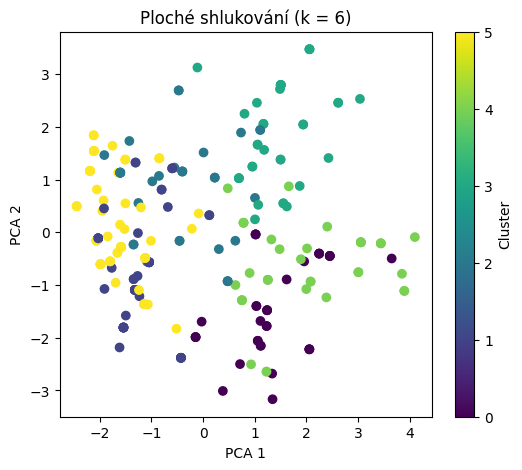

In [96]:
# PCA na 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup_scaled)


# finální model (k = 6)
kmeans_model = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans_model.fit_predict(X_unsup_scaled)

# graf
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans)
plt.title("Ploché shlukování (k = 6)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

Každý bod = každý pacient.  
Barva = cluster (K=means) 

#### 5.2.2 Hierarchické shlukování

In [97]:
## KÓD
# stejný počet shluků (k=6) jako u plochého shlukování, aby bylo možné výsledky porovnat
agg_model = AgglomerativeClustering(n_clusters=6)
labels_agg = agg_model.fit_predict(X_unsup_scaled)

df_agg_temp = df_unsup.copy()
df_agg_temp["cluster_agg"] = labels_agg

print("Počet lidí ve shlucích:")
print(df_agg_temp["cluster_agg"].value_counts().sort_index())

print("Průměry:")
display(df_agg_temp.groupby("cluster_agg").mean(numeric_only=True))

Počet lidí ve shlucích:
cluster_agg
0    67
1    57
2    39
3    47
4    21
5    27
Name: count, dtype: int64
Průměry:


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster_agg,,,,,,,,,,,,,,,,,
0,44.000000,0.850746,1.0,0.611940,0.462687,0.522388,0.164179,0.582090,0.328358,0.432836,0.208955,0.343284,0.268657,0.179104,0.388060,0.119403,0.940299
1,59.035088,0.631579,1.0,0.894737,0.543860,0.894737,0.719298,0.298246,0.894737,0.736842,0.438596,0.543860,0.789474,0.333333,0.175439,0.140351,1.000000
2,62.102564,0.743590,1.0,0.307692,0.435897,0.487179,0.923077,0.256410,0.538462,0.487179,0.641026,0.589744,0.410256,0.846154,0.897436,0.487179,0.717949
3,41.446809,0.042553,1.0,0.978723,0.893617,0.936170,0.787234,0.000000,0.659574,0.787234,0.531915,0.829787,1.000000,0.829787,0.000000,0.021277,1.000000
4,51.380952,0.095238,1.0,1.000000,1.000000,1.000000,0.666667,0.000000,1.000000,0.142857,0.000000,0.238095,0.952381,0.571429,0.000000,0.952381,1.000000
5,46.666667,0.111111,1.0,0.814815,0.851852,0.555556,1.000000,0.037037,0.000000,0.259259,0.000000,0.629630,0.814815,0.037037,0.000000,0.000000,1.000000


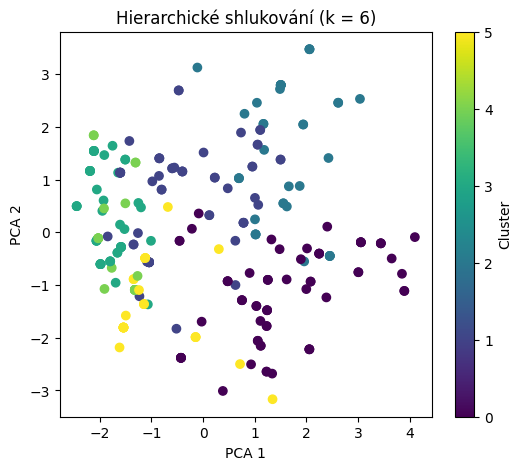

In [98]:
# model
agg_model = AgglomerativeClustering(n_clusters=6)
labels_agg = agg_model.fit_predict(X_unsup_scaled)

# graf
plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_agg)
plt.title("Hierarchické shlukování (k = 6)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 6 Evaluace

### 6.1 Klasifikační model

In [99]:
## a) Vybrat nejvhodnější metriku pro náš dataset (správnost, Fmíra??, musíme ještě vymyslet)
## b) Porovnat výkonnostní metriky pro oba typy algoritmů (stromy a lesy) a vybrat ten lepší
## c) Dosadit výsledky našich modelů do matice nákladů a vybrat ten nejlepší z hlediska nákladů 
##    (chceme co nejnižší náklady)
## d) Vyzkoušet různé prahy pravděpodobnosti. Jaký práh dává nejnižší náklady?

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(x_train, y_train.squeeze()) 
    y_pred = model.predict(x_test)

    print(name)
    print(classification_report(y_test, y_pred))


    confusMatrix = confusion_matrix(y_test, y_pred)
    print(confusMatrix)
    total_cost = np.sum(confusMatrix * cost_matrix)
    print(f"Celkové náklady: {total_cost}")

    y_proba = model.predict_proba(x_test)[:, 1]
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_cost = float("inf")
    best_t = 0
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        confusMatrixThreash = confusion_matrix(y_test, y_pred)
        cost = np.sum(confusMatrixThreash*cost_matrix)

        if cost < best_cost:
            best_cost = cost
            best_t = t

    print("Best threshold:", best_t)
    print("Lowest cost:", best_cost)

Decision Tree
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        33
           1       1.00      0.97      0.99        71

    accuracy                           0.98       104
   macro avg       0.97      0.99      0.98       104
weighted avg       0.98      0.98      0.98       104

[[33  0]
 [ 2 69]]
Celkové náklady: 79
Best threshold: 0.1
Lowest cost: 79
Random Forest
              precision    recall  f1-score   support

           0       0.97      0.94      0.95        33
           1       0.97      0.99      0.98        71

    accuracy                           0.97       104
   macro avg       0.97      0.96      0.97       104
weighted avg       0.97      0.97      0.97       104

[[31  2]
 [ 1 70]]
Celkové náklady: 79
Best threshold: 0.45000000000000007
Lowest cost: 75


In [100]:
## e) Kvantifikujte vliv jednotlivých kroků předzpracování (například změny měřítka). 
##    Jak by se změnil prediktivní výkon, kdybyste tento krok neprovedli (nepovinné).

#x_train = train_balanced.drop(columns=["class"])
#y_train = train_balanced[["class"]]
x_train_raw = train.drop(columns=["class"])
y_train_raw = train[["class"]]
#x_test = test.drop(columns=['class'])
#y_test = test[['class']]

# without additional preprocess
model1 = RandomForestClassifier(random_state=42)
model1.fit(x_train_raw, y_train_raw.squeeze())
pred1 = model1.predict(x_test)

# with additional preprocess
model2 = RandomForestClassifier(random_state=42)
model2.fit(x_train, y_train.squeeze())
pred2 = model2.predict(x_test)

# compare F1
f1_raw = f1_score(y_test, pred1)
f1 = f1_score(y_test, pred2)

print(f"Bez overfittingu: {f1_raw}")
print(f"S overfittingem: {f1}")  

Bez overfittingu: 0.9929078014184397
S overfittingem: 0.9790209790209791


### 6.2 Shlukování

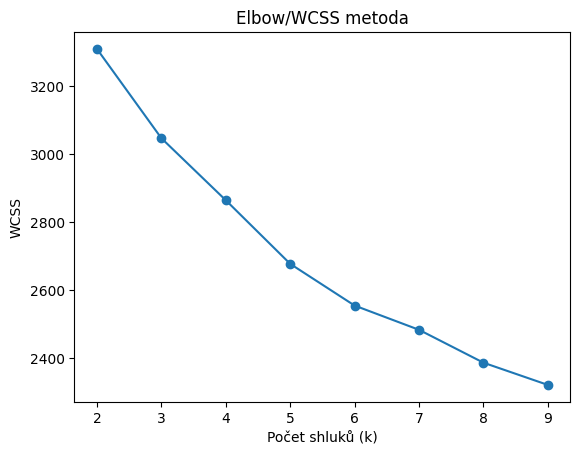

Spočítáme rozdíly
přechod: 2->3 ... 3308.34 - 3046.38 = 261.96
přechod: 3->4 ... 3046.38 - 2864.30 = 182.08
přechod: 4->5 ... 2864.30 - 2677.57 = 186.73
přechod: 5->6 ... 2677.57 - 2555.14 = 122.43
přechod: 6->7 ... 2555.14 - 2483.98 = 71.17
přechod: 7->8 ... 2483.98 - 2387.49 = 96.49
přechod: 8->9 ... 2387.49 - 2322.25 = 65.24


In [101]:
## a) Zdůvodnit zvolené k (počet shluků) pomocí grafu loketní křivky WCSS nebo Silhouette score

# WCSS metoda
wcss = []
# pro každou hodnotu pro k, vypočítáme wsss
for k in range(2, 10):
    kmeans_eval = KMeans(n_clusters=k, random_state=42)
    kmeans_eval.fit(X_unsup_scaled)
    wcss.append(kmeans_eval.inertia_)

plt.plot(range(2, 10), wcss, marker='o')
plt.xlabel("Počet shluků (k)")
plt.ylabel("WCSS")
plt.title("Elbow/WCSS metoda")
plt.show()

k_v_grafu = 2
print("Spočítáme rozdíly")
for i in range(len(wcss)-1):
    print(f"přechod: {k_v_grafu}->{k_v_grafu+1} ... {wcss[i]:.2f} - {wcss[i+1]:.2f} = {(wcss[i] - wcss[i+1]):.2f}")
    k_v_grafu +=1

Analýza poklesu hodnot WCSS ukázala, že výrazné zlepšení modelu probíhá do hodnoty k = 6. Po této hodnotě dochází k velkému zpomalení poklesu WCSS, proto optimální počet shluků je 6

In [102]:
## b) Vyhodnocení kvality shlukování pomocí některé z interních nebo externích metrik
# vypočítat silhouette score pro optimální k = 6
# KMeans/ ploché shlukování
kmeans_model = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans_model.fit_predict(X_unsup_scaled)
score_kmeans = silhouette_score(X_unsup_scaled, labels_kmeans)

print(f"Silhouette score (KMeans, k=6): {score_kmeans:.3f}")

# Hierarchické shlukování
agg_model = AgglomerativeClustering(n_clusters=6)
labels_agg = agg_model.fit_predict(X_unsup_scaled)
score_agg = silhouette_score(X_unsup_scaled, labels_agg)

print(f"Silhouette score (Hierarchické, k=6): {score_agg:.3f}")

Silhouette score (KMeans, k=6): 0.142
Silhouette score (Hierarchické, k=6): 0.113


Silhouette score bylo vypočteno pro oba algoritmy při k = 6.  
Pro ploché shlukování (KMeans) vyšla hodnota přibližně 0.13 a pro hierarchické shlukování vyšla hodnota přibližně 0.11.  

Vyšší hodnota u silhouette score znamená, že algoritmus vytvořil lépe shluky.  
U našeho případu silhouette score pro oba algoritmy jsou nízké, 0.13 a 0.11, což znamená, že struktura dat není dobře a silně shluková.
Shluky nejsou dobře oddělené a částečně se překrývají.

## 7 Interpretace dat

### 7.1 Klasifikace

In [103]:
## a) Určit nejdůležitější proměnné v modelu a vysvětlit jak model stromu dospěl ke svému 
##    závěru (které větve a uzly stromu byly aktivovány?)
## b) Použít oba modely (stromy i lesy) ke klasifikaci vybrané instance a určit spolehlivost 
##    (pravděpodobnost) predikce
## c) Pokud byste změnili hodnotu atributu zájmu, jak by se změnila klasifikace instance? 
##    V programu scikit-learn můžete použít graf ICE (volitelně)
## d) Použít LIME, SHAPLEY nebo Anchors k vysvětlení klasifikace instance (volitelně)

# a) Nejdůležitější atributy podle rozhodovacího stromu a náhodného lesu
tree_importance = pd.Series(decisionTreeClasiffier.feature_importances_, index=x_train.columns).sort_values(ascending=False)
forest_importance = pd.Series(randomForestClassifier.feature_importances_, index=x_train.columns).sort_values(ascending=False)

print("Top 5 atributů - rozhodovací strom:")
print(tree_importance.head(5))
print("\nTop 5 atributů - náhodný les:")
print(forest_importance.head(5))

# b) Klasifikace vybrané instance oběma modely
instance = x_test.iloc[[0]]
print("\nVybraná instance:")
print(instance)

tree_pred = decisionTreeClasiffier.predict(instance)[0]
tree_prob = decisionTreeClasiffier.predict_proba(instance)[0][1]

forest_pred = randomForestClassifier.predict(instance)[0]
forest_prob = randomForestClassifier.predict_proba(instance)[0][1]

print(f"\nStrom - predikce: {tree_pred}, pravděpodobnost pozitivní: {tree_prob:.2f}")
print(f"Les   - predikce: {forest_pred}, pravděpodobnost pozitivní: {forest_prob:.2f}")

# c) Změna atributu zájmu (Polydipsia) a porovnání výsledku
instance_changed = instance.copy()
instance_changed["Polydipsia"] = 1 - instance_changed["Polydipsia"].values[0]

print(f"\nPo změně Polydipsia:")
print(f"Strom - pravděpodobnost pozitivní: {decisionTreeClasiffier.predict_proba(instance_changed)[0][1]:.2f}")
print(f"Les   - pravděpodobnost pozitivní: {randomForestClassifier.predict_proba(instance_changed)[0][1]:.2f}")

Top 5 atributů - rozhodovací strom:
Polyuria      0.503325
Gender        0.086193
Age           0.072605
Alopecia      0.070329
Polydipsia    0.062053
dtype: float64

Top 5 atributů - náhodný les:
Polyuria       0.246778
Polydipsia     0.174786
Age            0.095414
Gender         0.091879
weight_loss    0.075870
dtype: float64

Vybraná instance:
     Age  Gender  Polyuria  Polydipsia  weight_loss  weakness  Polyphagia  \
275   72       1         1           0            0         0           1   

     Genital_thrush  visual_blurring  Itching  Irritability  delayed_healing  \
275               0                1        1             0                1   

     partial_paresis  muscle_stiffness  Alopecia  Obesity  
275                1                 1         1        0  

Strom - predikce: 0, pravděpodobnost pozitivní: 0.00
Les   - predikce: 0, pravděpodobnost pozitivní: 0.00

Po změně Polydipsia:
Strom - pravděpodobnost pozitivní: 0.00
Les   - pravděpodobnost pozitivní: 0.47


### 7.2 Shlukování

In [104]:
## a) Interpretovat konečné shluky na základě jejich centroidů a počtu instancí v každém shluku
## b) Pomocí modelu dosadit vybranou instanci do shluku a zkontrolovat přiřazený shluk
## c) Shoduje se hodnota cílové třídy v datech s nejčastější třídou v přiřazeném shluku (nepovinné)?
# a) Finální shlukování (k=2) - počet instancí a centroidy
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_unsup_scaled)

df_final = df_unsup.copy()
df_final["cluster"] = labels

print("Počet instancí v jednotlivých shlucích:")
print(df_final["cluster"].value_counts().sort_index())

print("\nCentroidy (průměry atributů v každém shluku):")
display(df_final.groupby("cluster").mean(numeric_only=True))

# b) Zařazení vybrané instance do shluku
instance_idx = 0
instance = X_unsup_scaled[instance_idx:instance_idx+1]
cluster_id = kmeans.predict(instance)[0]

print(f"\nVybraná instance byla přiřazena do shluku: {cluster_id}")

# c) Porovnání skutečné třídy instance s nejčastější třídou ve shluku
skutecna_trida = df_unsup.iloc[instance_idx]["class"]
nejcastejsi_trida = df_final[df_final["cluster"] == cluster_id]["class"].mode()[0]

print(f"Skutečná třída instance: {skutecna_trida}")
print(f"Nejčastější třída ve shluku {cluster_id}: {nejcastejsi_trida}")
print("Shoduje se:", skutecna_trida == nejcastejsi_trida)


Počet instancí v jednotlivých shlucích:
cluster
0    115
1    143
Name: count, dtype: int64

Centroidy (průměry atributů v každém shluku):


,Age,Gender,Polyuria,Polydipsia,weight_loss,weakness,Polyphagia,Genital_thrush,visual_blurring,Itching,Irritability,delayed_healing,partial_paresis,muscle_stiffness,Alopecia,Obesity,class
cluster,,,,,,,,,,,,,,,,,
0,52.191304,0.86087,1.0,0.486957,0.513043,0.521739,0.513043,0.521739,0.417391,0.513043,0.417391,0.460870,0.330435,0.391304,0.591304,0.260870,0.869565
1,49.090909,0.20979,1.0,0.958042,0.741259,0.874126,0.748252,0.048951,0.685315,0.545455,0.286713,0.594406,0.909091,0.496503,0.020979,0.181818,1.000000



Vybraná instance byla přiřazena do shluku: 0
Skutečná třída instance: 1
Nejčastější třída ve shluku 0: 1
Shoduje se: True


## 8 Závěr

## Závěr by měl být jen textový
## Shrnout výsledky a odpovědět na následující otázky:
## 1. Který výsledek strojového učení má nejvyšší hodnotu a je nejzajímavější? 

## 2. Jaké nastavení poskytlo nejlepší výsledek? 
## 3. Které atributy jsou nejdůležitější?

V této práci jsme porovnali dva klasifikační přístupy pro predikci rizika diabetu, konkrétně rozhodovací strom a náhodné lesy, a zároveň jsme testovali učení bez učitele, konkrétně ploché a hierarchické shlukování. Pro klasifikaci byl rozhodovací strom nastaven s parametrem _max_depth = 8_, zatímco náhodný les byl trénován na stejných předzpracovaných datech s 100 stromy a maximální hloubkou 11. V předzpracování byla data rozdělena na trénovací a testovací část s _test_size = 0.2_ a trénovací sada byla vyvažována pomocí oversamplingu.
Za nejzajímavější výsledek lze podle struktury notebooku považovat náhodné lesy, protože právě tento model je dále interpretován pomocí důležitosti atributů a slouží jako hlavní model pro vysvětlení predikce. U shlukování byly vyzkoušeny různé hodnoty počtu shluků _k=2,3,4,5,6_ a jako nejvhodnější byla v notebooku zvolena varianta _k=6_, podle křivky WCSS. Silhouette score pro _k = 6_ pro ploché shlukování se rovná 0.134 a pro hierarchické se rovná 1.144, což znamená, že shlukovací modely nejsou ideální pro náš problém. 
Z hlediska důležitosti atributů vyšel jako nejvýznamnější atribut polyuria, který měl v grafu Random Forestu nejvyšší hodnotu importance. Notebook zároveň uvádí, že cílem interpretace bylo sledovat, které proměnné mají největší vliv na výslednou predikci a jak model k rozhodnutí dospěl. Celkově tedy práce potvrzuje, že dobře zvolený klasifikační model společně s vhodným předzpracováním dat umožňuje smysluplně odhadovat riziko diabetu a zároveň identifikovat nejdůležitější symptomy.


# Závěrečný kontrolní seznam 

* Jsou všechny kroky předzpracování zdůvodněné?
* Vyzkoušeli jste různé hodnoty metaparametrů modelovacích algoritmů?
* Jsou výsledky opakovatelné? Pokud máte k dispozici stejná data, popisuje zpráva všechny kroky dostatečně podrobně, abyste získali stejné výsledky?
* Byly zvoleny správné hodnotící metriky? Jsou výsledky správně interpretovány?
* Jsou všechny důležité kroky vysvětleny a zdůvodněny?
* Jaká je kvalita textu? Je jazyk jasný a stručný?

# SMAZAT TUTO BUŇKU NA KONCI!!!
